## Notebook Description

Shapley/LMG variance-attribution analogue of `threshold_variance_attribution.ipynb`, applied to
the migrated H-mode confinement database/scaling.

**Selection**: `SELDB5 == 1` AND `PHASE` starting with `"HG"` or `"HS"` (ELMy H-mode).

**Machines**: `ASDEX, AUG, AUG-W, CMOD, COMPASS, D3D, JET`.

**Regressor set**: `ne, Bt, Ip, Ploss, eps, elongation, major_radius, isotope_mass`, categorical
`heating_scheme` (`has_ICRH`/`has_ECRH`, not mutually exclusive), plus `machine_offset` and
per-machine slopes for `Ip`/`Bt`/`ne`.

In [ ]:
import itertools
import math
from collections.abc import Iterable

import numpy as np
import matplotlib.pyplot as plt

import _simdb_common as sc

db = sc.get_db()
MACHINES = ["ASDEX", "AUG", "CMOD", "COMPASS", "D3D", "JET"]
ICRH_COMBOS = {"IC", "NBIC", "NBECIC", "ECIC"}  # any ICRH component present
ECRH_COMBOS = {"EC", "NBEC", "ECOA", "ECIC", "NBECIC"}  # any ECRH component present


def load_pooled(
    dataset: str, selec_key: str, machines: list[str], phase_prefixes: tuple[str, ...] | None = None
) -> np.ndarray:
    """SELEC-flagged slices for a set of machines, with every variable this notebook tests.

    phase_prefixes, if given, further restricts to db_variable.PHASE values starting with one of
    the given prefixes (e.g. ("HG", "HS") for ELMy H-mode)
    """
    rows = []
    for machine in machines:
        sims = sc.query_selected(db, dataset, selec_key, machine=machine)
        for sim in sims:
            md = sim.meta_dict()
            selec = sc.temp(md, selec_key, n=0)
            n = len(selec)
            if n == 0:
                continue
            bt = sc.path(md, "global_quantities", "b0", "value", n=n)
            ne = sc.path(md, "line_average", "n_e", "value", n=n)
            plth = sc.path(md, "global_quantities", "power_loss", "value", n=n)
            tau = sc.path(md, "global_quantities", "tau_energy", "value", n=n)
            meff = sc.path(md, "volume_average", "meff_hydrogenic", "value", n=n)
            kappa = sc.path(md, "boundary", "elongation", "value", n=n)
            rgeo = sc.path(md, "boundary", "geometric_axis_r", "value", n=n)
            amin = sc.path(md, "boundary", "minor_radius", "value", n=n)
            ip = sc.path(md, "global_quantities", "ip", "value", n=n)
            phase_raw = md.get("db_variable", {}).get("PHASE")

            n_slices = min(len(a) for a in (selec, bt, ne, plth, tau, meff, kappa, rgeo, amin, ip))
            if n_slices == 0:
                continue
            sel_mask = selec[:n_slices] == 1
            if phase_prefixes is not None:
                if phase_raw is None:
                    continue
                phase_ok = np.array([
                    isinstance(p, str) and p.startswith(phase_prefixes) for p in phase_raw[:n_slices]
                ])
                sel_mask = sel_mask & phase_ok
            if not sel_mask.any():
                continue
            auxheat_raw = md.get("db_variable", {}).get("AUXHEAT")
            for i in np.nonzero(sel_mask)[0]:
                ah = auxheat_raw[i] if auxheat_raw is not None and i < len(auxheat_raw) else None
                rows.append((machine, bt[i], ne[i], plth[i], tau[i], meff[i], kappa[i],
                             rgeo[i], amin[i], ip[i], ah))

    dtype = [("machine", "U8"), ("bt", float), ("ne", float), ("plth", float), ("tau", float),
             ("meff", float), ("kappa", float), ("rgeo", float), ("amin", float),
             ("ip", float), ("auxheat", object)]
    return np.array(rows, dtype=dtype)


def valid_mask(d: np.ndarray) -> np.ndarray:
    """All core variables finite/positive; shared by every analysis below."""
    return (
        np.isfinite(d["bt"]) & np.isfinite(d["ne"]) & np.isfinite(d["plth"]) & np.isfinite(d["tau"])
        & np.isfinite(d["kappa"]) & np.isfinite(d["rgeo"]) & np.isfinite(d["amin"]) & np.isfinite(d["ip"])
        & np.isfinite(d["meff"]) & (d["meff"] > 0)
        & (d["plth"] > 0) & (d["tau"] > 0) & (d["ne"] > 0) & (d["kappa"] > 0)
        & (d["rgeo"] > 0) & (d["amin"] > 0) & (d["ip"] != 0)
        & (d["auxheat"] != None)
    )


def _sum_to_zero_codes(machine: np.ndarray, machines: list[str]) -> np.ndarray:
    """Unweighted sum-to-zero (effect) contrast codes for an *arbitrary* list of k machines,
    returned as k-1 columns so every machine ends up with its own free deviation parameter 
    that sums to zero across all k.
    """
    ref = machines[-1]
    cols = [np.where(machine == m, 1.0, np.where(machine == ref, -1.0, 0.0)) for m in machines[:-1]]
    return np.column_stack(cols) if cols else np.zeros((len(machine), 0))


def machine_slope_blocks(machine: np.ndarray, machines: list[str], **named_vars: np.ndarray) -> dict[str, np.ndarray]:
    """Machine-specific variable interaction blocks for capturing device-specific slope
    heterogeneity, on top of machine_offset's flat per-machine level shift."""
    codes = _sum_to_zero_codes(machine, machines)
    return {
        f"machine_{name}": np.column_stack([codes[:, j] * v for j in range(codes.shape[1])])
        for name, v in named_vars.items()
    }


def named_blocks(d: np.ndarray, machines: list[str]) -> dict[str, np.ndarray]:
    """Final candidate blocks for the pooled hmode confinement-time analysis"""
    log_ne = np.log(d["ne"] / 1e19)
    log_bt = np.log(np.abs(d["bt"]))
    log_ip = np.log(np.abs(d["ip"]) / 1e6)
    has_icrh = np.isin(d["auxheat"], list(ICRH_COMBOS)).astype(float)
    has_ecrh = np.isin(d["auxheat"], list(ECRH_COMBOS)).astype(float)
    blocks = {
        "ne": log_ne.reshape(-1, 1),
        "Bt": log_bt.reshape(-1, 1),
        "Ploss": np.log(d["plth"] / 1e6).reshape(-1, 1),
        "eps": np.log(d["amin"] / d["rgeo"]).reshape(-1, 1),
        "elongation": np.log(d["kappa"]).reshape(-1, 1),
        "Ip": log_ip.reshape(-1, 1),
        "major_radius": np.log(d["rgeo"]).reshape(-1, 1),
        "isotope_mass": np.log(d["meff"]).reshape(-1, 1),
        "heating_scheme": np.column_stack([has_icrh, has_ecrh]),
        "machine_offset": _sum_to_zero_codes(d["machine"], machines),
    }
    blocks.update(machine_slope_blocks(d["machine"], machines, ip=log_ip, bt=log_bt, ne=log_ne))
    return blocks


component_colors = {
    "baseline": "#999999", "ne": "tab:pink", "Bt": "tab:brown", "Ploss": "gold",
    "eps": "tab:olive", "elongation": "tab:green", "Ip": "tab:cyan",
    "heating_scheme": "tab:blue", "machine_offset": "tab:purple",
    "machine_ip": "tab:cyan", "machine_bt": "tab:brown", "machine_ne": "tab:pink",
    "isotope_mass": "indigo", "major_radius": "tab:red", "unexplained": "#dddddd",
}

In [18]:
def shapley_r2(y: np.ndarray, base_cols: np.ndarray, blocks: dict[str, np.ndarray]) -> dict[str, float]:
    """Shapley/LMG decomposition of R^2 among candidate predictor blocks, on top of an
    always-included baseline.

    y: response (1D). base_cols: baseline design matrix, shape: (n_samples, n_base_cols), included in
    every model. blocks: {name: value.shape=(n_samples, n_block_cols)} candidate predictor groups.

    Returns {name: attributed R^2 share}, plus 'baseline' (R^2 with no blocks) and
    'unexplained' (1 - R^2 with all blocks). All values sum to exactly 1.
    """
    names = list(blocks.keys())
    K = len(names)

    def r2_for(subset_names):
        X = np.column_stack([base_cols] + [blocks[n] for n in subset_names])
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ coef
        return 1 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    r2_cache = {
        frozenset(combo): r2_for(combo)
        for r in range(K + 1) for combo in itertools.combinations(names, r)
    }

    shapley = {}
    for g in names:
        others = [n for n in names if n != g]
        total = 0.0
        for r in range(len(others) + 1):
            weight = math.factorial(r) * math.factorial(K - r - 1) / math.factorial(K)
            for combo in itertools.combinations(others, r):
                s = frozenset(combo)
                total += weight * (r2_cache[s | {g}] - r2_cache[s])
        shapley[g] = total

    return {"baseline": r2_for([]), **shapley, "unexplained": 1 - r2_for(names)}


## Analysis: pooled H-mode confinement time, all 6 machines

In [19]:
dA = load_pooled("hmode", "SELDB5", MACHINES, phase_prefixes=("HG", "HS"))
dA = dA[valid_mask(dA)]
print(f"N = {len(dA)}")

yA = np.log(dA["tau"])
baseA = np.ones(len(dA)).reshape(-1, 1)
resultA = shapley_r2(yA, baseA, named_blocks(dA, MACHINES))
assert abs(sum(resultA.values()) - 1.0) < 1e-9
resultA


N = 5665


{'baseline': np.float64(-2.220446049250313e-16),
 'ne': np.float64(0.01369374444171638),
 'Bt': np.float64(0.008664643475209762),
 'Ploss': np.float64(0.10354805064302232),
 'eps': np.float64(0.02874559350582389),
 'elongation': np.float64(0.02067168675574146),
 'Ip': np.float64(0.1445933961023991),
 'major_radius': np.float64(0.1040622050514728),
 'isotope_mass': np.float64(0.009973247475611926),
 'heating_scheme': np.float64(0.020822414649831398),
 'machine_offset': np.float64(0.12020171917005759),
 'machine_ip': np.float64(0.1496781950036796),
 'machine_bt': np.float64(0.11365858608210117),
 'machine_ne': np.float64(0.11453204534694833),
 'unexplained': np.float64(0.04715447229638492)}

## Per-machine log-linear scalings

fit `log(tau) ~ 1 + log(Ip) + log(Bt) + log(ne) + log(Ploss) + log(eps) + log(elongation)` independently on each machine's own data.


In [20]:
def fit_loglinear(label, y, fixed=None, **regressors):
    names = list(regressors)
    n = len(y)
    X = np.column_stack([np.ones(n)] + [np.log(regressors[k]) for k in names])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ coef
    p = X.shape[1]
    sigma2 = np.sum(resid**2) / max(n - p, 1)
    se = np.sqrt(np.diag(sigma2 * np.linalg.pinv(X.T @ X)))
    rmse = np.sqrt(np.mean(resid**2))
    r2 = 1.0 - np.sum(resid**2) / np.sum((y - y.mean())**2)

    print(f"{label}: N={n}")
    print(f"  C (multiplying factor) = {np.exp(coef[0]):.4g}   [offset = {coef[0]:+.3f} +/- {se[0]:.3f}]")
    for name, val in (fixed or {}).items():
        print(f"  {name} exponent = {val:+.3f} (fixed)")
    for j, name in enumerate(names, start=1):
        print(f"  {name} exponent = {coef[j]:+.3f} +/- {se[j]:.3f}")
    print(f"  RMSE(log) = {rmse:.3f}   R^2 = {r2:.3f}")
    return coef, se


for m in MACHINES:
    dm = dA[dA["machine"] == m]
    fit_loglinear(
        m, np.log(dm["tau"]),
        Ip=np.abs(dm["ip"]) / 1e6, Bt=np.abs(dm["bt"]), ne=dm["ne"] / 1e19,
        Ploss=dm["plth"] / 1e6, eps=dm["amin"] / dm["rgeo"], elongation=dm["kappa"],
    )
    print()


ASDEX: N=431
  C (multiplying factor) = 0.02826   [offset = -3.566 +/- 0.189]
  Ip exponent = +1.813 +/- 0.048
  Bt exponent = -0.126 +/- 0.052
  ne exponent = +0.675 +/- 0.021
  Ploss exponent = -0.926 +/- 0.016
  eps exponent = -1.524 +/- 0.126
  elongation exponent = -13.809 +/- 0.513
  RMSE(log) = 0.072   R^2 = 0.929

AUG: N=2133
  C (multiplying factor) = 0.4123   [offset = -0.886 +/- 0.188]
  Ip exponent = +1.637 +/- 0.032
  Bt exponent = -0.446 +/- 0.033
  ne exponent = -0.146 +/- 0.019
  Ploss exponent = -0.666 +/- 0.012
  eps exponent = +0.286 +/- 0.122
  elongation exponent = +1.171 +/- 0.184
  RMSE(log) = 0.185   R^2 = 0.770

CMOD: N=45
  C (multiplying factor) = 3.269   [offset = +1.184 +/- 3.144]
  Ip exponent = +0.844 +/- 0.188
  Bt exponent = -0.884 +/- 0.646
  ne exponent = +0.281 +/- 0.136
  Ploss exponent = -0.851 +/- 0.132
  eps exponent = +2.896 +/- 2.529
  elongation exponent = +1.193 +/- 0.748
  RMSE(log) = 0.087   R^2 = 0.718

COMPASS: N=16
  C (multiplying facto

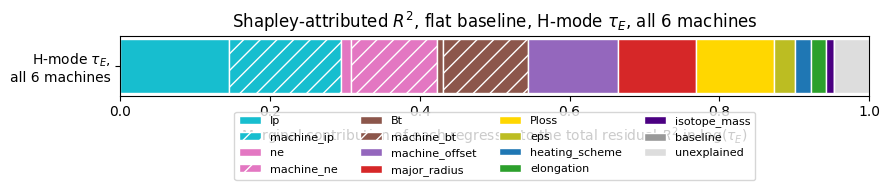

In [27]:
pair_map = {"Ip": "machine_ip", "Bt": "machine_bt", "ne": "machine_ne"}
machine_slope_comps = set(pair_map.values())
primary = [k for k in resultA if k not in machine_slope_comps and k != "unexplained"]


def pair_total(k):
    return resultA[k] + resultA.get(pair_map.get(k, ""), 0.0)


component_order = []
for k in sorted(primary, key=pair_total, reverse=True):
    component_order.append(k)
    if pair_map.get(k) in resultA:
        component_order.append(pair_map[k])
component_order.append("unexplained")

fig, ax = plt.subplots(figsize=(9, 2.2))
labels = ["H-mode $\\tau_E$,\nall 6 machines"]
bottoms = np.zeros(len(labels))
for comp in component_order:
    vals = np.array([resultA[comp]])
    hatch = "//" if comp in machine_slope_comps else None
    ax.barh(labels, vals, left=bottoms, color=component_colors[comp], label=comp, edgecolor="white", hatch=hatch)
    bottoms += vals

ax.set_xlabel(r"Marginal contribution of each regressor to the total residual $R^2$ in $\log(\tau_E)$")
ax.set_xlim(0, 1)
ax.set_title(r"Shapley-attributed $R^2$, flat baseline, H-mode $\tau_E$, all 6 machines")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, fontsize=8)
fig.tight_layout()
